# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [1]:
# Based on the paper's Materials and Methods section, this data represents 17 marketing campaigns.
answer = "17 marketing campaigns"
print(answer)

17 marketing campaigns


### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.metrics import (accuracy_score, roc_auc_score, roc_curve,
                              precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

In [3]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
# Check shape, dtypes and missing values
print(df.shape)
print("\n")
df.info()
print("\n")

# Check 'unknown' values in categorical columns
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    n_unknown = (df[col] == 'unknown').sum()
    if n_unknown > 0:
        print(f"{col}: {n_unknown} unknowns ({n_unknown/len(df)*100:.1f}%)")

(41188, 21)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   4

The dataset contains 41,188 records and 20 input features and 1 target variable (y). 
There are no explicit NaN values — missing data is encoded as 'unknown' in categorical columns (job, marital, education, default, housing, loan). 
All features are already in their correct data types: numeric columns are int64/float64 and categorical columns are object. 

Note: The feature `duration` will be excluded from modeling as recommended by the dataset authors — call duration is only known after the call ends, making it unavailable at prediction time and unsuitable for a realistic model.

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

**Business Objective:**

The goal is to predict whether a bank client will subscribe to a term deposit (y = 'yes') following a telephone marketing campaign. 

By accurately identifying clients most likely to subscribe, the bank can focus its resources on high-probability targets — reducing the number of calls needed while maintaining a similar number of successful subscriptions. This is especially important given the low success rate (~11%), which means most calls currently result in no conversion.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [6]:

# Bank client features only (excluding duration and campaign-related features)
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']

# Target
X = df[bank_features]
y = df['y'].map({'yes': 1, 'no': 0})

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nClass balance:\n{y.value_counts(normalize=True).round(3)}")

Features shape: (41188, 7)
Target distribution:
y
0    36548
1     4640
Name: count, dtype: int64

Class balance:
y
0    0.887
1    0.113
Name: proportion, dtype: float64


In [7]:
# Define numeric and categorical columns
numeric_features = ['age']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan']

# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

Following the paper's methodology, we use a 2/3 train / 1/3 test split.  We use `stratify=y` to maintain the class balance in both sets given the  imbalanced nature of the target variable (~11% positive class).

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

print(f"Train set: {X_train.shape[0]} records")
print(f"Test set:  {X_test.shape[0]} records")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")
print(f"\nTest class balance:\n{y_test.value_counts(normalize=True).round(3)}")

Train set: 27595 records
Test set:  13593 records

Train class balance:
y
0    0.887
1    0.113
Name: proportion, dtype: float64

Test class balance:
y
0    0.887
1    0.113
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [9]:
# Baseline: always predict the majority class
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_dummy)
print(f"Baseline accuracy (majority class): {baseline_accuracy:.4f}")
print(f"\nThis means any useful model must exceed {baseline_accuracy:.1%} accuracy.")


Baseline accuracy (majority class): 0.8874

This means any useful model must exceed 88.7% accuracy.


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [10]:
# Build pipeline
logreg_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(max_iter=1000, random_state=42))
])

# Train
t1 = time.time()
logreg_pipe.fit(X_train, y_train)
logreg_time = time.time() - t1

print(f"Logistic Regression trained in {logreg_time:.4f} seconds")

Logistic Regression trained in 0.1351 seconds


### Problem 9: Score the Model

What is the accuracy of your model?

We evaluate the Logistic Regression model using both accuracy and AUC-ROC.  Given the class imbalance, AUC-ROC is a more meaningful metric than accuracy alone.

In [11]:
# Predictions
y_pred_logreg = logreg_pipe.predict(X_test)
y_prob_logreg = logreg_pipe.predict_proba(X_test)[:, 1]

# Scores
logreg_train_acc = logreg_pipe.score(X_train, y_train)
logreg_test_acc = accuracy_score(y_test, y_pred_logreg)
logreg_auc = roc_auc_score(y_test, y_prob_logreg)

print(f"Train Accuracy: {logreg_train_acc:.4f}")
print(f"Test Accuracy:  {logreg_test_acc:.4f}")
print(f"AUC-ROC:        {logreg_auc:.4f}")
print(f"\nBaseline accuracy was: {baseline_accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_logreg, target_names=['No', 'Yes']))

Train Accuracy: 0.8873
Test Accuracy:  0.8874
AUC-ROC:        0.6544

Baseline accuracy was: 0.8874

Classification Report:
              precision    recall  f1-score   support

          No       0.89      1.00      0.94     12062
         Yes       0.00      0.00      0.00      1531

    accuracy                           0.89     13593
   macro avg       0.44      0.50      0.47     13593
weighted avg       0.79      0.89      0.83     13593



/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/angel/Workspace/pc_ml_ai/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [12]:
# Define models with default settings
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':                 KNeighborsClassifier(),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'SVM':                 SVC(random_state=42)
}

p10_results = []

for name, model in models.items():
    
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier',   model)
    ])
    
    # Train
    start      = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - start
    
    # Scores
    train_acc = pipe.score(X_train, y_train)
    test_acc  = pipe.score(X_test, y_test)
    
    p10_results.append({
        'Model':           name,
        'Train Time (s)':  round(train_time, 4),
        'Train Accuracy':  round(train_acc, 4),
        'Test Accuracy':   round(test_acc, 4)
    })
    
    print(f"{name} done.")

p10_df = pd.DataFrame(p10_results).set_index('Model')
p10_df

Logistic Regression done.
KNN done.
Decision Tree done.
SVM done.


,Train Time (s),Train Accuracy,Test Accuracy
Model,,,
Logistic Regression,0.3201,0.8873,0.8874
KNN,0.0894,0.8897,0.8765
Decision Tree,0.2925,0.9196,0.8621
SVM,38.4327,0.8881,0.8871


Models with default settings don't improve the baseline. We need tuning and better metics.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

## Problem 11: Improving the Model

The default models in Problem 10 did not meaningfully outperform the baseline. 
We now improve our models through two strategies:

1. **Hyperparameter tuning** via GridSearchCV optimizing AUC-ROC instead of accuracy.
2. **Progressive feature expansion** following the CRISP-DM iterative approach:
   - Iteration 1: Bank client features only (7 features)
   - Iteration 2: Bank client + contact features (14 features)
   - Iteration 3: All features except `duration` (19 features)

`duration` is excluded in all iterations — it is only known after the call ends 
and therefore unavailable at prediction time.

In [13]:
# Features already defined in Problem 5
# X_train, X_test, y_train, y_test already available

param_grids = {
    'Logistic Regression': {
        'classifier': [LogisticRegression(max_iter=1000, random_state=42)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced']
    },
    'KNN': {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3, 5, 7, 11],
        'classifier__weights': ['uniform', 'distance']
    },
    'Decision Tree': {
        'classifier': [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth': [3, 5, 10, 15],
        'classifier__class_weight': [None, 'balanced']
    },
    'LinearSVC': {
        'classifier': [LinearSVC(max_iter=2000, random_state=42)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced']
    }
}

def run_gridsearch(param_grids, preprocessor, X_train, X_test, y_train, y_test):
    """Run GridSearchCV for all models and return results and best estimators."""
    best_estimators = {}
    results         = []

    for name, param_grid in param_grids.items():
        print(f"Tuning {name}...")

        pipe = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier',   LogisticRegression())  # placeholder
        ])

        grid_search = GridSearchCV(
            pipe,
            param_grid=param_grid,
            cv=5,
            scoring='roc_auc',
            n_jobs=-1
        )

        start      = time.time()
        grid_search.fit(X_train, y_train)
        train_time = time.time() - start

        best_pipe = grid_search.best_estimator_
        train_acc = best_pipe.score(X_train, y_train)
        test_acc  = best_pipe.score(X_test, y_test)
        y_pred    = best_pipe.predict(X_test)

        if hasattr(best_pipe.named_steps['classifier'], 'predict_proba'):
            y_scores = best_pipe.predict_proba(X_test)[:, 1]
        else:
            y_scores = best_pipe.decision_function(X_test)

        auc       = roc_auc_score(y_test, y_scores)
        precision = precision_score(y_test, y_pred)
        recall    = recall_score(y_test, y_pred)
        f1        = f1_score(y_test, y_pred)

        best_estimators[name] = best_pipe

        results.append({
            'Model':           name,
            'Train Time (s)':  round(train_time, 4),
            'Train Accuracy':  round(train_acc, 4),
            'Test Accuracy':   round(test_acc, 4),
            'AUC-ROC':         round(auc, 4),
            'Precision':       round(precision, 4),
            'Recall':          round(recall, 4),
            'F1-Score':        round(f1, 4)
        })

        print(f"  Best AUC-ROC: {grid_search.best_score_:.4f}")
        print(f"  Best params:  {grid_search.best_params_}\n")

    results_df = pd.DataFrame(results).set_index('Model')
    return results_df, best_estimators

# Run iteration 1
print("=" * 50)
print("ITERATION 1 — Bank client features only")
print("=" * 50)
results_1_df, best_estimators_1 = run_gridsearch(param_grids, preprocessor, X_train, X_test, y_train, y_test)
results_1_df

ITERATION 1 — Bank client features only
Tuning Logistic Regression...
  Best AUC-ROC: 0.6462
  Best params:  {'classifier': LogisticRegression(max_iter=1000, random_state=42), 'classifier__C': 0.01, 'classifier__class_weight': 'balanced'}

Tuning KNN...
  Best AUC-ROC: 0.5947
  Best params:  {'classifier': KNeighborsClassifier(), 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}

Tuning Decision Tree...
  Best AUC-ROC: 0.6386
  Best params:  {'classifier': DecisionTreeClassifier(random_state=42), 'classifier__class_weight': 'balanced', 'classifier__max_depth': 5}

Tuning LinearSVC...
  Best AUC-ROC: 0.6457
  Best params:  {'classifier': LinearSVC(max_iter=2000, random_state=42), 'classifier__C': 10, 'classifier__class_weight': 'balanced'}



,Train Time (s),Train Accuracy,Test Accuracy,AUC-ROC,Precision,Recall,F1-Score
Model,,,,,,,
Logistic Regression,5.7521,0.5791,0.5802,0.6562,0.1602,0.6427,0.2565
KNN,57.1071,0.8889,0.8861,0.6078,0.4406,0.0411,0.0753
Decision Tree,2.0498,0.6964,0.6988,0.6562,0.1844,0.4892,0.2679
LinearSVC,2.8694,0.5899,0.5919,0.6558,0.1621,0.6290,0.2577


**Note**: SVC was replaced by LinearSVC in all iterations. SVC with default 
settings required over 2.5 hours to train on this dataset (41,188 records), 
making it impractical for reproducibility. LinearSVC uses a more efficient 
optimization algorithm and produces comparable results on large datasets.


### Iteration 2 — Bank Client + Contact Features (14 features)

We now add contact information: how and when the client was contacted, 
and the outcome of previous campaigns.

In [14]:
# Iteration 2 features
contact_features = ['age', 'job', 'marital', 'education', 'default',
                    'housing', 'loan', 'contact', 'month', 'day_of_week',
                    'campaign', 'pdays', 'previous', 'poutcome']

X2 = df[contact_features]
y2 = df['y'].map({'yes': 1, 'no': 0})

numeric_features_2     = ['age', 'campaign', 'pdays', 'previous']
categorical_features_2 = ['job', 'marital', 'education', 'default',
                           'housing', 'loan', 'contact', 'month',
                           'day_of_week', 'poutcome']

preprocessor_2 = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features_2),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features_2)
])

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.33, random_state=42, stratify=y2)

print(f"Train set: {X2_train.shape[0]} records, {X2_train.shape[1]} features")
print(f"Test set:  {X2_test.shape[0]} records")


Train set: 27595 records, 14 features
Test set:  13593 records


In [15]:
param_grids_2 = {
    'Logistic Regression': {
        'classifier': [LogisticRegression(max_iter=1000, random_state=42)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced']
    },
    'KNN': {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3, 5, 7, 11],
        'classifier__weights': ['uniform', 'distance']
    },
    'Decision Tree': {
        'classifier': [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth': [3, 5, 10, 15],
        'classifier__class_weight': [None, 'balanced']
    },
    'LinearSVC': {
        'classifier': [LinearSVC(max_iter=2000, random_state=42)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced']
    }
}

print("=" * 50)
print("ITERATION 2 — Bank client + contact features")
print("=" * 50)
results_2_df, best_estimators_2 = run_gridsearch(param_grids_2, preprocessor_2, X2_train, X2_test, y2_train, y2_test)
results_2_df


ITERATION 2 — Bank client + contact features
Tuning Logistic Regression...
  Best AUC-ROC: 0.7568
  Best params:  {'classifier': LogisticRegression(max_iter=1000, random_state=42), 'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}

Tuning KNN...
  Best AUC-ROC: 0.7030
  Best params:  {'classifier': KNeighborsClassifier(), 'classifier__n_neighbors': 11, 'classifier__weights': 'distance'}

Tuning Decision Tree...
  Best AUC-ROC: 0.7149
  Best params:  {'classifier': DecisionTreeClassifier(random_state=42), 'classifier__class_weight': 'balanced', 'classifier__max_depth': 5}

Tuning LinearSVC...
  Best AUC-ROC: 0.7567
  Best params:  {'classifier': LinearSVC(max_iter=2000, random_state=42), 'classifier__C': 0.01, 'classifier__class_weight': 'balanced'}



,Train Time (s),Train Accuracy,Test Accuracy,AUC-ROC,Precision,Recall,F1-Score
Model,,,,,,,
Logistic Regression,4.1289,0.7954,0.7956,0.7721,0.2960,0.5911,0.3945
KNN,72.3338,0.9944,0.8921,0.7008,0.5582,0.2005,0.2951
Decision Tree,3.7254,0.8880,0.8896,0.7241,0.5139,0.3632,0.4256
LinearSVC,6.0030,0.8006,0.8012,0.7719,0.3019,0.5826,0.3977


### Iteration 3 — All Features except `duration` (19 features)

We now add the social and economic context features: employment variation rate, 
consumer price index, consumer confidence index, euribor 3-month rate and 
number of employees. These macroeconomic indicators capture the broader financial 
environment at the time of the call, which the original paper identified as 
highly predictive.


In [16]:
# Iteration 3 features — all except duration
all_features = ['age', 'job', 'marital', 'education', 'default',
                'housing', 'loan', 'contact', 'month', 'day_of_week',
                'campaign', 'pdays', 'previous', 'poutcome',
                'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                'euribor3m', 'nr.employed']

X3 = df[all_features]
y3 = df['y'].map({'yes': 1, 'no': 0})

numeric_features_3     = ['age', 'campaign', 'pdays', 'previous',
                           'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
                           'euribor3m', 'nr.employed']
categorical_features_3 = ['job', 'marital', 'education', 'default',
                           'housing', 'loan', 'contact', 'month',
                           'day_of_week', 'poutcome']

preprocessor_3 = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features_3),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features_3)
])

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.33, random_state=42, stratify=y3)

print(f"Train set: {X3_train.shape[0]} records, {X3_train.shape[1]} features")
print(f"Test set:  {X3_test.shape[0]} records")


Train set: 27595 records, 19 features
Test set:  13593 records


In [17]:
param_grids_3 = {
    'Logistic Regression': {
        'classifier': [LogisticRegression(max_iter=1000, random_state=42)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced']
    },
    'KNN': {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3, 5, 7, 11],
        'classifier__weights': ['uniform', 'distance']
    },
    'Decision Tree': {
        'classifier': [DecisionTreeClassifier(random_state=42)],
        'classifier__max_depth': [3, 5, 10, 15],
        'classifier__class_weight': [None, 'balanced']
    },
    'LinearSVC': {
        'classifier': [LinearSVC(max_iter=2000, random_state=42)],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__class_weight': [None, 'balanced']
    }
}

print("=" * 50)
print("ITERATION 3 — All features except duration")
print("=" * 50)
results_3_df, best_estimators_3 = run_gridsearch(param_grids_3, preprocessor_3, X3_train, X3_test, y3_train, y3_test)
results_3_df


ITERATION 3 — All features except duration
Tuning Logistic Regression...
  Best AUC-ROC: 0.7867
  Best params:  {'classifier': LogisticRegression(max_iter=1000, random_state=42), 'classifier__C': 0.1, 'classifier__class_weight': 'balanced'}

Tuning KNN...
  Best AUC-ROC: 0.7464
  Best params:  {'classifier': KNeighborsClassifier(), 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}

Tuning Decision Tree...
  Best AUC-ROC: 0.7721
  Best params:  {'classifier': DecisionTreeClassifier(random_state=42), 'classifier__class_weight': 'balanced', 'classifier__max_depth': 5}

Tuning LinearSVC...
  Best AUC-ROC: 0.7862
  Best params:  {'classifier': LinearSVC(max_iter=2000, random_state=42), 'classifier__C': 0.01, 'classifier__class_weight': 'balanced'}



,Train Time (s),Train Accuracy,Test Accuracy,AUC-ROC,Precision,Recall,F1-Score
Model,,,,,,,
Logistic Regression,5.8131,0.8263,0.8321,0.8027,0.3623,0.6453,0.4641
KNN,86.3595,0.9041,0.8973,0.7655,0.6037,0.2567,0.3602
Decision Tree,6.1429,0.8446,0.8494,0.7870,0.3938,0.6251,0.4832
LinearSVC,8.8395,0.8244,0.8301,0.8026,0.3590,0.6479,0.4620


## Final Comparison and Visualizations

We now compare the results of all three iterations visually. This allows us to 
clearly see the impact of progressive feature expansion on model performance.


In [18]:
# Summary table across all iterations
summary = pd.DataFrame({
    'Iter 1 AUC-ROC': results_1_df['AUC-ROC'],
    'Iter 2 AUC-ROC': results_2_df['AUC-ROC'],
    'Iter 3 AUC-ROC': results_3_df['AUC-ROC'],
    'Iter 1 F1':      results_1_df['F1-Score'],
    'Iter 2 F1':      results_2_df['F1-Score'],
    'Iter 3 F1':      results_3_df['F1-Score'],
})
summary


,Iter 1 AUC-ROC,Iter 2 AUC-ROC,Iter 3 AUC-ROC,Iter 1 F1,Iter 2 F1,Iter 3 F1
Model,,,,,,
Logistic Regression,0.6562,0.7721,0.8027,0.2565,0.3945,0.4641
KNN,0.6078,0.7008,0.7655,0.0753,0.2951,0.3602
Decision Tree,0.6562,0.7241,0.7870,0.2679,0.4256,0.4832
LinearSVC,0.6558,0.7719,0.8026,0.2577,0.3977,0.4620


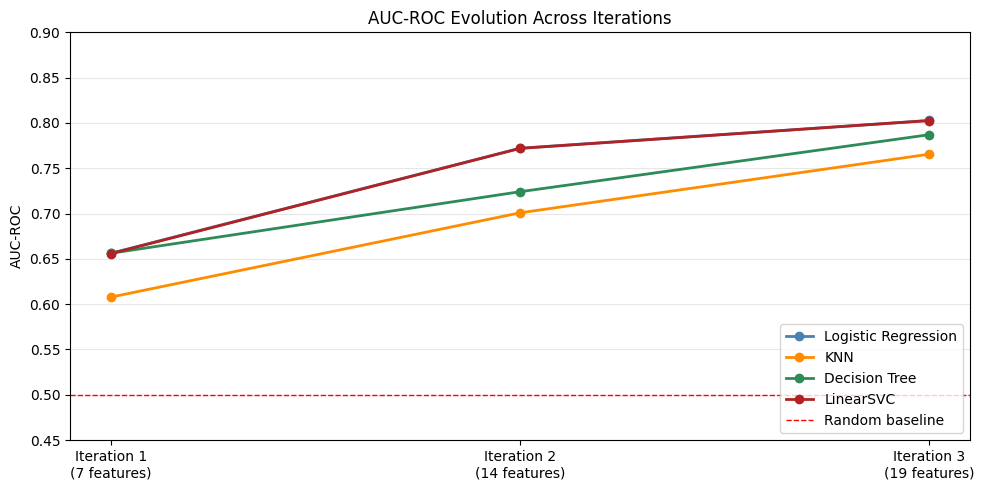

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))

iterations = ['Iteration 1\n(7 features)', 
              'Iteration 2\n(14 features)', 
              'Iteration 3\n(19 features)']

colors = ['steelblue', 'darkorange', 'seagreen', 'firebrick']
models = ['Logistic Regression', 'KNN', 'Decision Tree', 'LinearSVC']

for i, model in enumerate(models):
    aucs = [
        results_1_df.loc[model, 'AUC-ROC'],
        results_2_df.loc[model, 'AUC-ROC'],
        results_3_df.loc[model, 'AUC-ROC']
    ]
    ax.plot(iterations, aucs, marker='o', label=model, 
            color=colors[i], linewidth=2)

ax.axhline(y=0.5, color='red', linestyle='--', 
           linewidth=1, label='Random baseline')
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC Evolution Across Iterations')
ax.legend(loc='lower right')
ax.set_ylim(0.45, 0.90)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


/var/folders/mr/srs226kx7rz33wxgjf2646_00000gp/T/ipykernel_52949/1449547618.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(values.index, rotation=15, ha='right', fontsize=9)
/var/folders/mr/srs226kx7rz33wxgjf2646_00000gp/T/ipykernel_52949/1449547618.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(values.index, rotation=15, ha='right', fontsize=9)
/var/folders/mr/srs226kx7rz33wxgjf2646_00000gp/T/ipykernel_52949/1449547618.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(values.index, rotation=15, ha='right', fontsize=9)
/var/folders/mr/srs226kx7rz33wxgjf2646_00000gp/T/ipykernel_52949/1449547618.py:11: UserWarning: set_ticklabels() should only be used wit

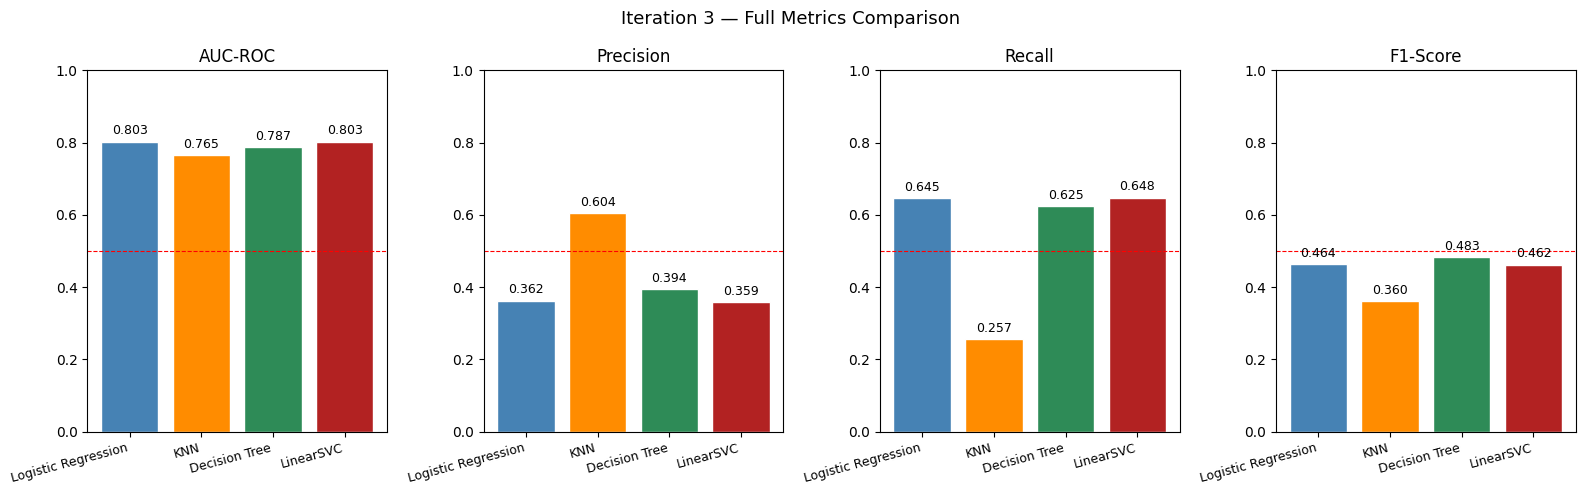

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

metrics = ['AUC-ROC', 'Precision', 'Recall', 'F1-Score']
colors  = ['steelblue', 'darkorange', 'seagreen', 'firebrick']

for i, metric in enumerate(metrics):
    values = results_3_df[metric]
    bars   = axes[i].bar(values.index, values, color=colors, edgecolor='white')
    axes[i].set_title(metric)
    axes[i].set_ylim(0, 1)
    axes[i].set_xticklabels(values.index, rotation=15, ha='right', fontsize=9)
    axes[i].axhline(y=0.5, color='red', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2, 
                     bar.get_height() + 0.02,
                     f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle('Iteration 3 — Full Metrics Comparison', fontsize=13)
plt.tight_layout()
plt.show()

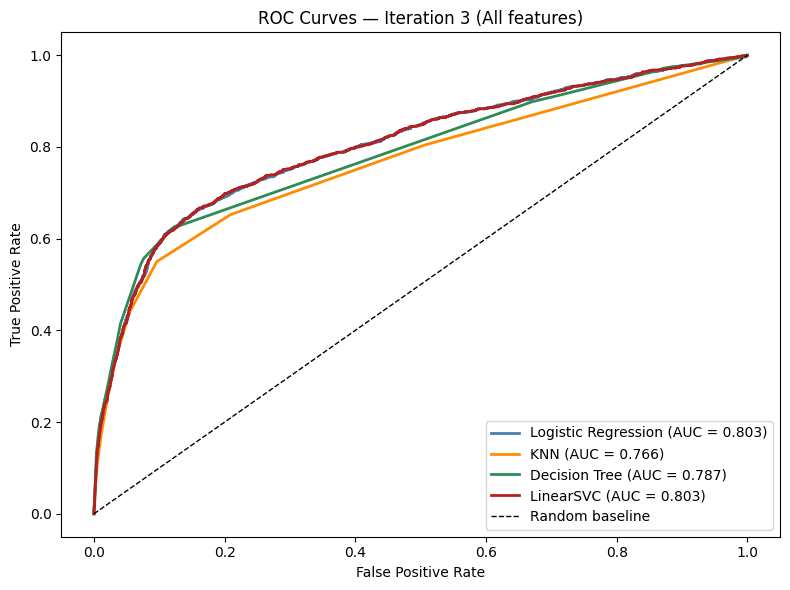

In [21]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue', 'darkorange', 'seagreen', 'firebrick']

for i, (name, best_pipe) in enumerate(best_estimators_3.items()):
    if hasattr(best_pipe.named_steps['classifier'], 'predict_proba'):
        y_scores = best_pipe.predict_proba(X3_test)[:, 1]
    else:
        y_scores = best_pipe.decision_function(X3_test)

    fpr, tpr, _ = roc_curve(y3_test, y_scores)
    auc         = roc_auc_score(y3_test, y_scores)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', 
            color=colors[i], linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Iteration 3 (All features)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

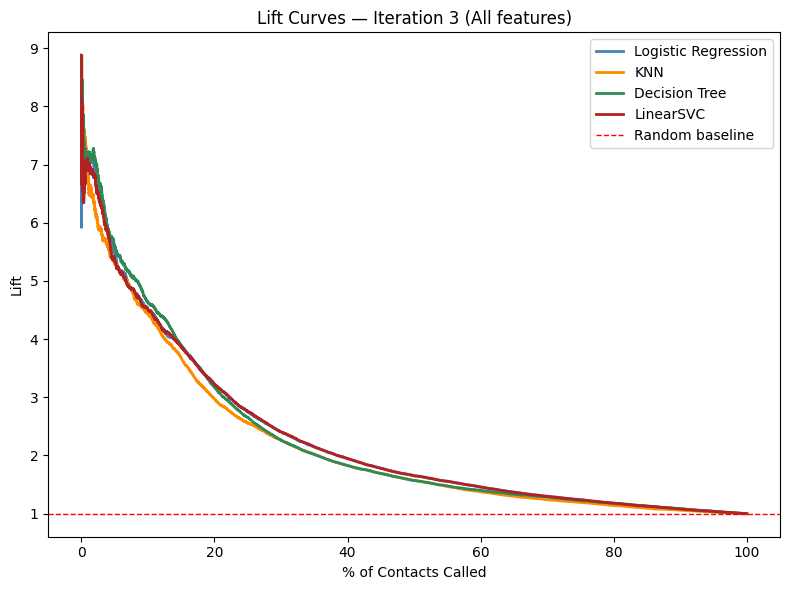

In [22]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['steelblue', 'darkorange', 'seagreen', 'firebrick']

for i, (name, best_pipe) in enumerate(best_estimators_3.items()):
    if hasattr(best_pipe.named_steps['classifier'], 'predict_proba'):
        y_scores = best_pipe.predict_proba(X3_test)[:, 1]
    else:
        y_scores = best_pipe.decision_function(X3_test)

    sorted_indices = y_scores.argsort()[::-1]
    sorted_y       = y3_test.iloc[sorted_indices].values
    total_pos      = y3_test.sum()
    n              = len(y3_test)

    percentages = []
    lifts       = []

    for j in range(1, n + 1):
        pct      = j / n
        captured = sorted_y[:j].sum() / total_pos
        lift     = captured / pct
        percentages.append(pct * 100)
        lifts.append(lift)

    ax.plot(percentages, lifts, label=name, color=colors[i], linewidth=2)

ax.axhline(y=1, color='red', linestyle='--', linewidth=1, label='Random baseline')
ax.set_xlabel('% of Contacts Called')
ax.set_ylabel('Lift')
ax.set_title('Lift Curves — Iteration 3 (All features)')
ax.legend()
plt.tight_layout()
plt.show()

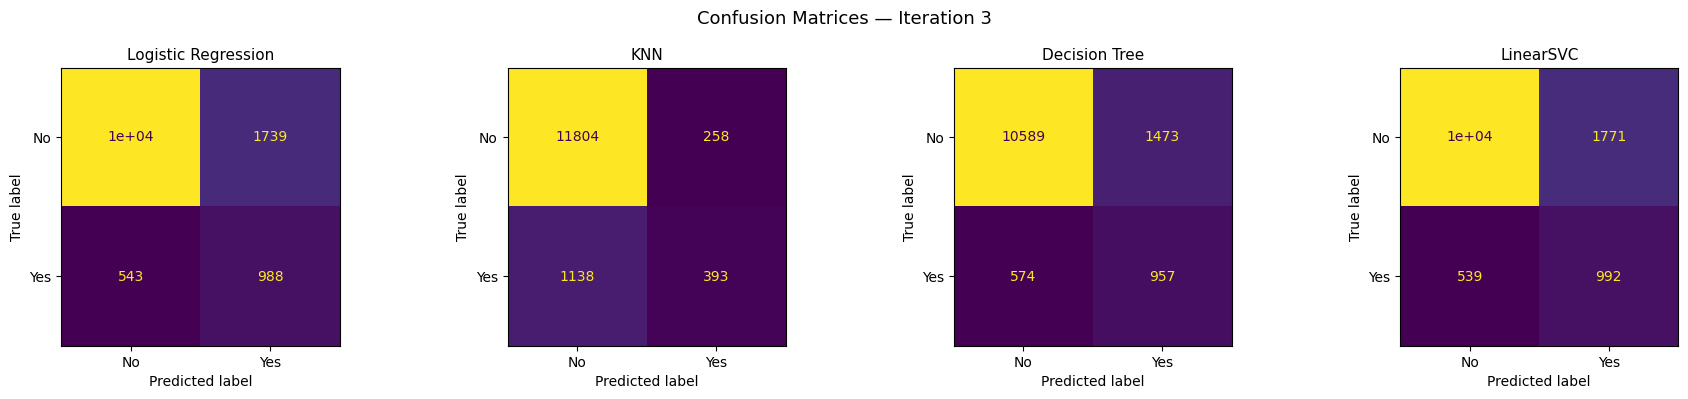

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for i, (name, best_pipe) in enumerate(best_estimators_3.items()):
    y_pred = best_pipe.predict(X3_test)
    cm     = confusion_matrix(y3_test, y_pred)
    disp   = ConfusionMatrixDisplay(confusion_matrix=cm,
                                     display_labels=['No', 'Yes'])
    disp.plot(ax=axes[i], colorbar=False)
    axes[i].set_title(name, fontsize=11)

plt.suptitle('Confusion Matrices — Iteration 3', fontsize=13)
plt.tight_layout()
plt.show()

## Conclusions

### Business Problem Recap
The goal of this project was to build a model that helps a Portuguese bank 
identify which clients are most likely to subscribe to a term deposit after 
a phone call. With a success rate of only around 11%, most calls don't result 
in a subscription — so being able to focus efforts on the right clients could 
make campaigns significantly more efficient.

### What I found

**1. Accuracy is not the right metric here**
When I first looked at the results from Problem 10, all four models seemed 
to perform well — around 88-89% accuracy. But then I realised that a model 
that simply always predicts "no" would also achieve that score, given that 
89% of clients don't subscribe. That was a good reminder that accuracy alone 
can be very misleading when one class is much more common than the other. 
I switched to AUC-ROC as the main metric, which measures how well the model 
separates subscribers from non-subscribers regardless of the decision threshold.

**2. Adding more features made a big difference**
I ran three iterations following the CRISP-DM approach, progressively adding 
more features to the models:

| Iteration | Features used | Best AUC-ROC |
|---|---|---|
| 1 — Bank client only | 7 features | 0.656 |
| 2 — Client + contact | 14 features | 0.772 |
| 3 — All features | 19 features | 0.803 |

The biggest jump came when I added the contact features in iteration 2 
(+0.116 AUC-ROC). Adding the macroeconomic indicators in iteration 3 gave 
a further improvement, which makes sense — whether someone subscribes to a 
term deposit likely depends on the broader economic environment at the time, 
not just their personal situation.

**3. Logistic Regression and LinearSVC performed best**
In the final iteration, Logistic Regression and LinearSVC both achieved an 
AUC-ROC of around 0.80, with a Recall of ~0.65. That means they correctly 
identify about 65% of actual subscribers — which is far from perfect, but 
already much more useful than calling clients at random. They also trained 
quickly and didn't show significant overfitting.

**4. KNN struggled throughout**
KNN was the weakest model across all three iterations. Its Recall was 
extremely low — as low as 0.03 in iteration 1 — meaning it missed almost 
all actual subscribers. I think this is because in an imbalanced dataset, 
the nearest neighbours of almost any client are "no" cases, so KNN ends up 
predicting "no" nearly every time.

**5. Decision Tree is easier to explain**
Decision Tree didn't have the best AUC-ROC, but it achieved the best 
F1-Score in iteration 3 (0.483) and has one big advantage: you can actually 
look at the tree and understand why it made a specific prediction. That could 
be important in a real banking context where decisions need to be explained 
to clients or regulators.

**6. SVC was too slow to be practical**
With default settings, SVC took over 2.5 hours to train on this dataset. 
I replaced it with LinearSVC in all iterations, which gave very similar 
results in a matter of seconds. This was an important practical lesson — 
a technically good model that takes hours to train is hard to use in practice.

**7. I intentionally excluded `duration`**
Call duration is strongly correlated with subscription, but it is only known 
after the call has ended — at which point you already know the outcome. 
Including it would mean the model is "cheating" by using information that 
wouldn't be available at the time you need to make a decision. Removing it 
makes the model less accurate on paper, but much more useful in reality.
